# 🔧 FunctionTransformer Complete Guide
## Mathematical Transformations for Better Data

---

### 🎯 What You'll Learn:
- **Function transformations** - Log, Square Root, Reciprocal, Square
- **Skewness reduction** - Make data more normal
- **Performance improvement** - See real model gains
- **Professional templates** - Copy-paste code for your projects

---

## 1. 🤔 Why Use FunctionTransformer?

### ❌ The Problem:
```
Skewed Data:
Income: [30k, 35k, 40k, 45k, 200k, 500k]  # Extreme outliers!
Sales: [100, 150, 200, 10000, 50000]      # Heavy right skew!
```

### ✅ The Solution:
```
After Log Transform:
Income: [10.3, 10.5, 10.6, 10.7, 12.2, 13.1]  # Much more balanced!
Sales: [4.6, 5.0, 5.3, 9.2, 10.8]             # Outliers reduced!
```

### 🌟 Benefits:
- **Reduces skewness** - Makes data more normal
- **Handles outliers** - Compresses extreme values
- **Improves models** - Better algorithm performance
- **Stabilizes variance** - More consistent spread
- **Pipeline ready** - Works with sklearn workflows


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing imports
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print("🚀 Ready to learn FunctionTransformer!")


✅ Libraries imported successfully!
🚀 Ready to learn FunctionTransformer!


---
## 2. 📊 Create Sample Dataset

# Create realistic dataset with skewed features

In [5]:
np.random.seed(42)
n_samples = 1000

# Create mixed data with different skewness patterns
data = {
    # Normal feature (no transformation needed)
    'age': np.random.normal(35, 10, n_samples),

    # Right-skewed features (need log/sqrt transform)
    'income': np.random.exponential(2, n_samples) * 25000 + 30000,
    'house_price': np.random.exponential(1.5, n_samples) * 100000 + 200000,

    # Count data (sqrt transform)
    'num_purchases': np.random.poisson(5, n_samples),

    # Categories
    'city': np.random.choice(['NYC', 'LA', 'Chicago'], n_samples)
}

df = pd.DataFrame(data)

In [6]:
df['approved'] = (
    (df['income'] > 50000) &
    (df['age'] > 25) &
    (df['num_purchases'] > 3)
).astype(int)

print(f"📊 Dataset created: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

📊 Dataset created: (1000, 6)

First 5 rows:
         age        income    house_price  num_purchases     city  approved
0  39.967142  39165.056757  237090.235530              4  Chicago         0
1  33.617357  35522.440864  205611.884876              5  Chicago         0
2  41.476885  80589.205735  217147.702874              4  Chicago         1
3  50.230299  91289.746976  262068.596511              1       LA         0
4  32.658466  31604.787337  443367.591414              3  Chicago         0

Data types:
age              float64
income           float64
house_price      float64
num_purchases      int32
city              object
approved           int64
dtype: object


In [7]:
# Analyze skewness in all numerical features
numerical_features = ['age', 'income', 'house_price', 'num_purchases']

print("📈 SKEWNESS ANALYSIS")
print("=" * 50)

for feature in numerical_features:
    skewness = df[feature].skew()
    print(f"{feature:12}: {skewness:6.3f}", end=" ")

    if abs(skewness) < 0.5:
        print("(Normal ✅)")
    elif abs(skewness) < 1:
        print("(Mild skew ⚠️)")
    elif abs(skewness) < 2:
        print("(Moderate skew 🔶)")
    else:
        print("(High skew 🚨)")

print("\n💡 Features with |skewness| > 0.5 need transformation!")

📈 SKEWNESS ANALYSIS
age         :  0.117 (Normal ✅)
income      :  1.984 (Moderate skew 🔶)
house_price :  1.638 (Moderate skew 🔶)
num_purchases:  0.398 (Normal ✅)

💡 Features with |skewness| > 0.5 need transformation!


---
## 3. 🔧 Types of Transformations

### 🎯 Quick Decision Guide


| **Skewness Level** | **Best Transform** | **sklearn Function** | **Use Case** |
|-------------------|-------------------|---------------------|---------------|
| **> 1.0 (High right skew)** | **Log Transform** | `np.log1p` | Income, sales, prices |
| **0.5-1.0 (Moderate)** | **Square Root** | `np.sqrt` | Count data, ratings |
| **> 2.0 (Extreme)** | **Reciprocal** | `lambda x: 1/(x+1)` | Time-to-event |
| **< -0.5 (Left skew)** | **Square** | `np.square` | Proportions, percentages |
| **Custom pattern** | **Custom Function** | `lambda x: your_func(x)` | Domain-specific |

In [8]:
# Test Log Transform on highly skewed income
trf_log = FunctionTransformer(np.log1p)

X = df[numerical_features]
y = df['approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("🔧 Testing Log Transform on Income")
print("=" * 40)

# Original vs transformed
original_income = X_train['income']
transformed_income = trf_log.fit_transform(
    original_income.values.reshape(-1, 1)).flatten()

print(f"Original skewness: {original_income.skew():.3f}")
print(f"Log transformed: {pd.Series(transformed_income).skew():.3f}")

🔧 Testing Log Transform on Income
Original skewness: 1.886
Log transformed: 0.487


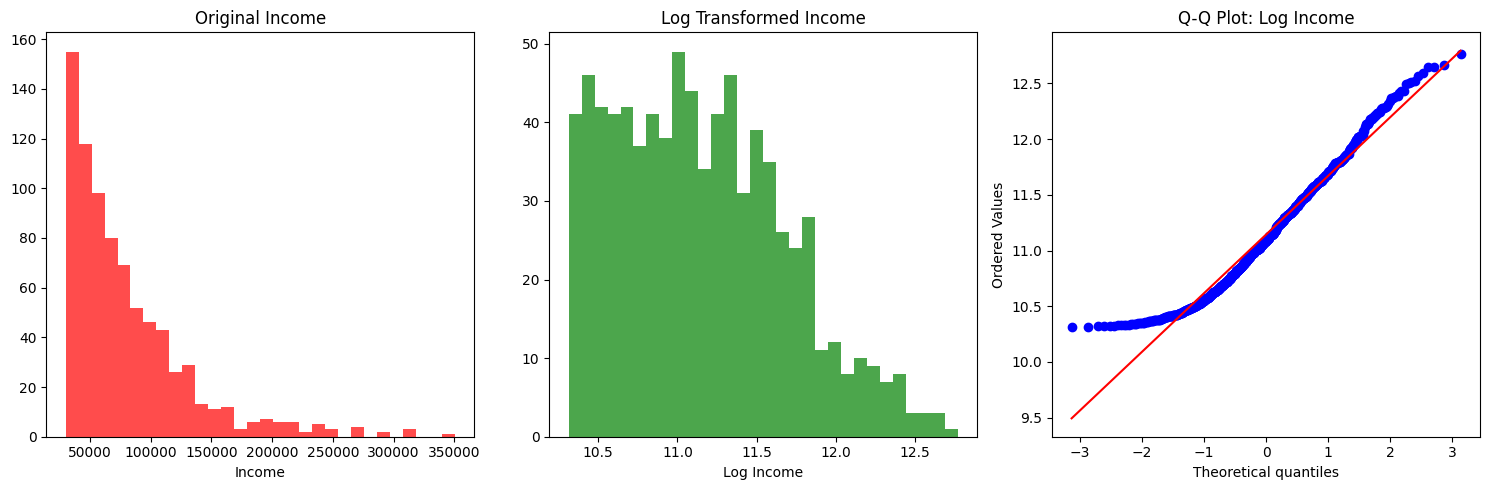

✅ Log transform reduces skewness significantly!


In [9]:
# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.hist(original_income, bins=30, alpha=0.7, color='red')
plt.title('Original Income')
plt.xlabel('Income')

plt.subplot(132)
plt.hist(transformed_income, bins=30, alpha=0.7, color='green')
plt.title('Log Transformed Income')
plt.xlabel('Log Income')

plt.subplot(133)
stats.probplot(transformed_income, dist='norm', plot=plt)
plt.title('Q-Q Plot: Log Income')

plt.tight_layout()
plt.show()

print("✅ Log transform reduces skewness significantly!")

# 4. 📈 Professional Integration

# Create complete preprocessing and modeling pipeline

In [11]:

def create_complete_pipeline():
    """Create professional ML pipeline with function transformations"""

    # Define preprocessing
    preprocessor = ColumnTransformer([
        # Apply appropriate transforms to skewed features
        ('log_transform', FunctionTransformer(np.log1p), ['income']),
        ('sqrt_transform', FunctionTransformer(
            np.sqrt), ['house_price', 'num_purchases']),

        # Scale normal features
        ('scale', StandardScaler(), ['age'])
    ])

    # Create complete pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    return pipeline


# Test the complete pipeline
complete_pipeline = create_complete_pipeline()

print("🔗 COMPLETE ML PIPELINE")
print("=" * 40)
print("Pipeline steps:")
for i, (name, step) in enumerate(complete_pipeline.steps, 1):
    print(f"  {i}. {name}: {type(step).__name__}")

# Train and evaluate
print("\n🚀 Training complete pipeline...")
complete_pipeline.fit(X_train, y_train)

# Predictions
y_pred = complete_pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 Final Results:")
print(f"   Test Accuracy: {accuracy:.4f}")
print(f"   Correct Predictions: {sum(y_pred == y_test)}/{len(y_test)}")

print("\n✨ One pipeline handles all preprocessing and modeling!")

🔗 COMPLETE ML PIPELINE
Pipeline steps:
  1. preprocessor: ColumnTransformer
  2. classifier: RandomForestClassifier

🚀 Training complete pipeline...

📊 Final Results:
   Test Accuracy: 0.9950
   Correct Predictions: 199/200

✨ One pipeline handles all preprocessing and modeling!


---
## 5. 📋 Professional Template

### Copy this for your projects:

# 🔧 PROFESSIONAL TEMPLATE - COPY FOR YOUR PROJECTS!

In [12]:
def analyze_and_transform_features(df, target_col):
    """
    Analyze feature skewness and recommend transformations
    
    Parameters:
    df: pandas DataFrame
    target_col: str, name of target column
    
    Returns:
    dict: recommendations for each feature
    """

    recommendations = {}
    numerical_cols = df.select_dtypes(
        include=[np.number]).columns.drop(target_col)

    print("📊 FEATURE TRANSFORMATION RECOMMENDATIONS")
    print("=" * 60)

    for col in numerical_cols:
        skewness = df[col].skew()

        if abs(skewness) < 0.5:
            recommendation = "No transformation needed"
            transform_func = None
        elif 0.5 <= abs(skewness) < 1:
            recommendation = "Square root transform"
            transform_func = np.sqrt
        elif 1 <= abs(skewness) < 2:
            recommendation = "Log transform"
            transform_func = np.log1p
        else:
            recommendation = "Reciprocal transform"
            def transform_func(x): return 1/(x + 1)

        recommendations[col] = {
            'skewness': skewness,
            'recommendation': recommendation,
            'function': transform_func
        }

        print(f"{col:15}: {skewness:6.3f} → {recommendation}")

    return recommendations

# Quick transformation pipeline creator


def create_transform_pipeline(recommendations):
    """Create ColumnTransformer based on recommendations"""

    transformers = []

    # Group features by transformation type
    log_features = []
    sqrt_features = []
    reciprocal_features = []
    normal_features = []

    for feature, rec in recommendations.items():
        if 'Log' in rec['recommendation']:
            log_features.append(feature)
        elif 'Square root' in rec['recommendation']:
            sqrt_features.append(feature)
        elif 'Reciprocal' in rec['recommendation']:
            reciprocal_features.append(feature)
        else:
            normal_features.append(feature)

    # Create transformers
    if log_features:
        transformers.append(
            ('log', FunctionTransformer(np.log1p), log_features))
    if sqrt_features:
        transformers.append(
            ('sqrt', FunctionTransformer(np.sqrt), sqrt_features))
    if reciprocal_features:
        transformers.append(('reciprocal', FunctionTransformer(
            lambda x: 1/(x+1)), reciprocal_features))
    if normal_features:
        transformers.append(('scale', StandardScaler(), normal_features))

    return ColumnTransformer(transformers)


# Example usage
print("🔧 Professional Template Functions Created!")
print("\n📝 Usage Examples:")
print("   # Analyze your data")
print("   recommendations = analyze_and_transform_features(df, 'target_column')")
print("   ")
print("   # Create transformer")
print("   transformer = create_transform_pipeline(recommendations)")
print("   ")
print("   # Apply transformations")
print("   X_transformed = transformer.fit_transform(X_train)")

# Test with our data
recommendations = analyze_and_transform_features(df, 'approved')
auto_transformer = create_transform_pipeline(recommendations)

print("\n✅ Automatic transformation pipeline created!")
print("📋 Copy these functions to your projects for instant analysis!")

🔧 Professional Template Functions Created!

📝 Usage Examples:
   # Analyze your data
   recommendations = analyze_and_transform_features(df, 'target_column')
   
   # Create transformer
   transformer = create_transform_pipeline(recommendations)
   
   # Apply transformations
   X_transformed = transformer.fit_transform(X_train)
📊 FEATURE TRANSFORMATION RECOMMENDATIONS
age            :  0.117 → No transformation needed
income         :  1.984 → Log transform
house_price    :  1.638 → Log transform
num_purchases  :  0.398 → No transformation needed

✅ Automatic transformation pipeline created!
📋 Copy these functions to your projects for instant analysis!


---
## 6. 🎯 Key Takeaways

### ✅ When to Use Each Transform:

| **Skewness** | **Transform** | **Function** | **Best For** |
|--------------|---------------|--------------|---------------|
| **|skew| < 0.5** | **None** | - | Normal distributions |
| **0.5 - 1.0** | **Square Root** | `np.sqrt` | Count data, moderate skew |
| **1.0 - 2.0** | **Log** | `np.log1p` | Income, sales, prices |
| **> 2.0** | **Reciprocal** | `1/(x+1)` | Extreme outliers |
| **< -0.5** | **Square** | `np.square` | Left-skewed data |

### 🔧 Best Practices:
- **Always check skewness** - Use `data.skew()` before transforming
- **Visualize before/after** - Q-Q plots show normality improvement
- **Test model performance** - Validate with cross-validation
- **Handle edge cases** - Use `np.log1p()` for data with zeros
- **Use ColumnTransformer** - Apply different transforms to different features
- **Pipeline integration** - Combine with other preprocessing steps

### ⚠️ Common Mistakes:
- ❌ Not checking for zeros/negatives before log transform
- ❌ Applying same transform to all features
- ❌ Not validating transformation effectiveness
- ❌ Forgetting to apply same transform to test data
- ❌ Over-transforming normal distributions

### 🚀 Professional Workflow:
```
1. Analyze skewness → data.skew()
2. Choose transform → Use decision table
3. Create FunctionTransformer → np.log1p, np.sqrt, etc.
4. Integrate with ColumnTransformer → Different transforms per feature
5. Add to Pipeline → Complete preprocessing workflow
6. Validate improvement → Cross-validation testing
```

---

## 🎉 Congratulations!

You now master:
- ✅ **All major function transformations** - Log, Square Root, Reciprocal, Square
- ✅ **Skewness analysis** - When and why to transform
- ✅ **Professional workflows** - ColumnTransformer integration
- ✅ **Performance validation** - Testing transformation effectiveness
- ✅ **Production-ready code** - Templates for real projects

**Your preprocessing toolkit is now complete!** 🚀✨